In [5]:
%%capture
!pip install datasets pandas scikit-learn
!pip install transformers torch
!pip install textblob



Importing libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, fbeta_score, roc_auc_score,roc_curve
from transformers import AutoTokenizer, AutoModel
import torch
from textblob import TextBlob


Loading the dataset

In [2]:

ds = load_dataset("cyberpsych/PubMed-Cancer-NLP-Textual-Dataset")
data = ds["train"].to_pandas()
print(data.head())

   Unnamed: 0  Cancer Type      PMID  \
0           0  bone cancer  39614431   
1           1  bone cancer  39614373   
2           2  bone cancer  39614338   
3           3  bone cancer  39614304   
4           4  bone cancer  39613747   

                                               Title  \
0  Signal Transduction Mechanisms of Focal Adhesi...   
1  Clinical efficacy on the reconstruction of bon...   
2  Gremlin-2 is a novel tumor suppressor that neg...   
3  Complete resection of a giant costal chondrosa...   
4  Multiple myeloma long-term survivors exhibit s...   

                                            Abstract  
0  Cell-to-substrate adhesion sites, also known a...  
1  To evaluate the clinical efficacy of modular h...  
2  Breast cancer is one of the most common cancer...  
3  Chondrosarcoma primarily occurs in the pelvis ...  
4  The long-term consequences of cancer and its t...  


Data cleaning

In [3]:

data = data.dropna(subset=["Title", "Abstract"]).copy()
data = data[data["Cancer Type"].notnull()]



In [4]:
print(data["Cancer Type"].unique())

['bone cancer' 'brain tumour' 'breast cancer' 'colon cancer'
 'gastric cancer' 'kidney cancer' 'lung cancer' 'ovarian cancer'
 'prostate cancer' 'skin cancer']


In [ ]:
#checking for empty strings
data = data[data["Title"].str.strip() != ""]
data = data[data["Abstract"].str.strip() != ""].copy()

In [ ]:
#creating the text column
data["text"]= data["Title"]+ "" + data["Abstract"]

In [ ]:
#count label distribution
print(data["Cancer Type"].value_counts())

Cancer Type
brain tumour       9736
bone cancer        9723
skin cancer        9718
prostate cancer    9701
kidney cancer      9687
ovarian cancer     9678
lung cancer        9664
breast cancer      9635
colon cancer       9620
gastric cancer     9523
Name: count, dtype: int64


Binary classification

In [ ]:

#1=aggressive cancers
#0= less aggressive cancers

high_risk= ["pancreatic Cancer", "lung Cancer", "colon cancer", "brain tumor"]
data["Cancer Type"] = data["Cancer Type"].apply(
    lambda x: 1 if x in high_risk else 0

)


Early detection labelling 

In [ ]:
early_keywords = [
    "stage i", "stage ii", "early stage", "localized",
    "no metastasis", "small tumor", "confined"
]

late_keywords = [
    "stage iii", "stage iv", "metastatic",
    "advanced", "invasive", "widespread"
]

def label_stage(text):
    text = str(text).lower()
    
    if any(k in text for k in late_keywords):
        return 1  
    elif any(k in text for k in early_keywords):
        return 0  
    else:
        return -1

data["stage_label"] = data["text"].apply(label_stage)
data = data[data["stage_label"] != -1]

Train test split 

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    data["text"],
    data["stage_label"],
    test_size=0.2,
    random_state=42,
    stratify=data["stage_label"]
)

Feature engineering and sentiment analysis

In [ ]:
#sentiment analysis
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity
data["sentiment_score"] = data["Abstract"].fillna("").map(get_sentiment)
print(data[["Abstract", "sentiment_score"]].head())

                                             Abstract  sentiment_score
11  A patient with a long history of bone predomin...         0.131250
15  Chronic inflammation plays a pivotal role in c...         0.066667
19  Tumour metastasis to the jaw is an uncommon fi...         0.063258
21  Currently, there is a paucity of data that des...         0.000000
25  Multiple myeloma (MM) is a plasma cell (PC) di...         0.093131


In [ ]:
#TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

tfidf_model = LogisticRegression(max_iter=1000, class_weight="balanced")
tfidf_model.fit(X_train_tfidf, y_train)

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = tfidf_model.coef_[0]
top_positive = feature_names[np.argsort(coefs)[-10:]]
top_negative = feature_names[np.argsort(coefs)[:10]]

print("Top positive words for high-risk cancers:", top_positive)
print("Top negative words for high-risk cancers:", top_negative)

Top positive words for high-risk cancers: ['oligometastatic' 'noninvasive' 'metastasis' 'iv' 'widespread' 'locally'
 'minimally' 'invasive' 'metastatic' 'advanced']
Top negative words for high-risk cancers: ['localized' 'stage' 'early' 'confined' 'ii' 'stages' 'recurrence' 'ia'
 'adjuvant' 'microglia']


Model training

In [ ]:

tfidf_model = LogisticRegression(max_iter=1000, class_weight="balanced")
tfidf_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
#make predictions 
y_pred = tfidf_model.predict(X_test_tfidf)


Performance evaluation

In [ ]:

#from sklearn.metrics import classification_report, fbeta_score
print(classification_report(y_test, y_pred))

# F2 score
f2 = fbeta_score(y_test, y_pred, beta=2)
print("F2 Score:", f2)


              precision    recall  f1-score   support

           0       0.63      0.85      0.72       371
           1       0.99      0.95      0.97      3752

    accuracy                           0.94      4123
   macro avg       0.81      0.90      0.84      4123
weighted avg       0.95      0.94      0.94      4123

F2 Score: 0.9562929553264605


Confusion matrix

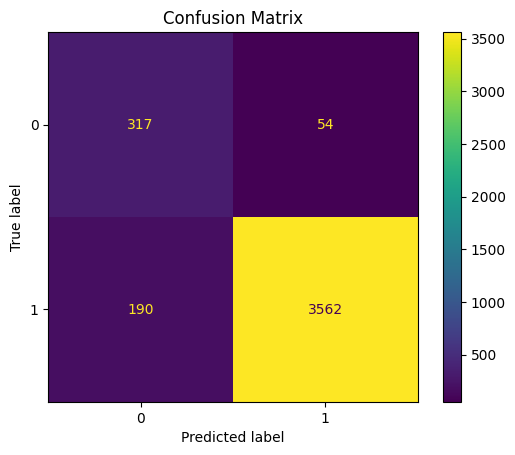

In [ ]:

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png") 
plt.show()

AUC-ROC evaluation

AUC: 0.9685127500732763


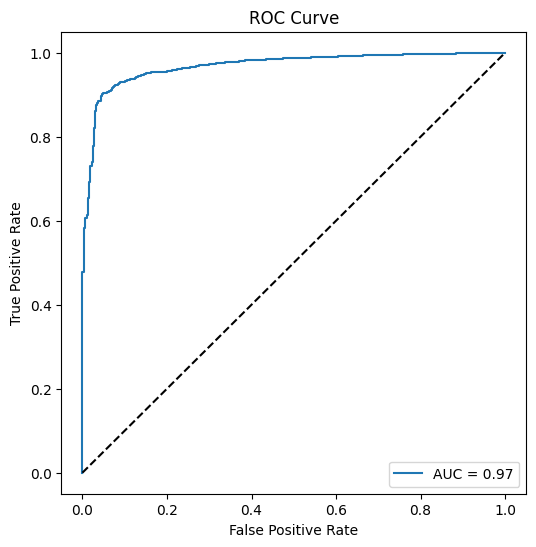

In [ ]:
#auc-roc evaluation
# Predict probabilities for the positive class
y_probs = tfidf_model.predict_proba(X_test_tfidf)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("AUC:", auc)

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
